# ECS7026P Neural Networks and Deep Learning
## Part 1: CIFAR-10 Classification

This notebook implements the attention-weighted convolutional architecture specified in the assignment brief, trains a baseline model, runs a set of screening experiments to identify the best capacity and training settings, and trains a final model on those settings.

In [1]:
# To run on Google Colab: Runtime > Change runtime type > Hardware accelerator > GPU (T4 recommended).

## 1. Setup

In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(123)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
    print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device")
else:
    device = torch.device("cpu")
    print("Using CPU")

USE_CUDA = device.type == "cuda"
NUM_WORKERS = 4 if USE_CUDA else 2
PIN_MEMORY = USE_CUDA


[HAMI-core Msg(356:140338075413824:libvgpu.c:839)]: Initializing.....


Using CUDA device: NVIDIA L40S


[HAMI-core Msg(356:140338075413824:libvgpu.c:855)]: Initialized


## 2. CIFAR-10 Data

Standard CIFAR-10 per-channel mean/std normalisation is applied to all splits. The training loader uses the chosen augmentation pipeline; a separate non-augmented training loader is used when evaluating training accuracy so that the train/test curves are comparable. Following the assignments guidance the test set is used as a validation set.

In [3]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


def make_transform(augmentation="none"):
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    if augmentation == "none":
        return test_tf
    if augmentation == "basic":
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
        ])
    if augmentation == "moderate":
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
        ])
    if augmentation == "strong":
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
            transforms.RandomErasing(p=0.5, scale=(0.02, 0.33)),
        ])
    raise ValueError(f"Unknown augmentation: {augmentation}")


def get_loaders(batch_size=128, augmentation="none"):
    train_ds = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=make_transform(augmentation)
    )
    train_eval_ds = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=make_transform("none")
    )
    test_ds = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=make_transform("none")
    )
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    train_eval_loader = DataLoader(
        train_eval_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    return train_loader, train_eval_loader, test_loader


train_loader, train_eval_loader, test_loader = get_loaders(
    batch_size=128, augmentation="none"
)
print(f"Training samples: {len(train_loader.dataset):,}")
print(f"Testing samples : {len(test_loader.dataset):,}")
print(f"Batches / epoch : {len(train_loader)}")


Training samples: 50,000
Testing samples : 10,000
Batches / epoch : 391


## 3. Architecture

The specific architecture the assignment brief specifies is implemented as follows:

- each intermediate block has L independent convolution branches;
- every branch receives the same input tensor x;
- branch weights come from a fully connected layer applied to the channel means of x;
- the block output is the weighted sum of the branch outputs;
- the output block uses channel means followed by fully connected layer(s) to produce
  the 10 logits.

Beyond the strict requirements of the brief, the following standard additions were made. BatchNorm2d is added after each convolution to keep activations on a consistent scale, which stabilises and speeds up training. ReLU is applied after each branch so the network can learn non-linear features — without it, the weighted sum collapses to a linear operation regardless of depth. MaxPool2d is placed between blocks to halve the spatial dimensions at each stage, forcing the network to build increasingly abstract representations as it gets deeper. `bias=False` is set on convolution layers because the batch normalisation that follows subtracts the channel mean anyway, making a learned bias redundant. Kaiming initialisation sets the starting weights to a scale appropriate for ReLU activations, avoiding gradients that vanish or explode in the first few training steps.

In [4]:
class IntermediateBlock(nn.Module):
    """
    Each branch receives the same input x. The channel mean of x is passed
    through a fully connected layer to produce branch weights, and the final
    block output is a weighted sum of independent convolution branch outputs.
    """
    def __init__(self, in_channels, out_channels, num_convs=3, kernel_sizes=3):
        super().__init__()
        if isinstance(kernel_sizes, int):
            kernel_sizes = [kernel_sizes] * num_convs
        assert len(kernel_sizes) == num_convs

        self.conv_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=ks,
                    padding=ks // 2, bias=False
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
            for ks in kernel_sizes
        ])
        self.attention_fc = nn.Linear(in_channels, num_convs)

    def forward(self, x):
        m = x.mean(dim=(2, 3))
        a = torch.softmax(self.attention_fc(m), dim=1)
        outs = torch.stack([conv(x) for conv in self.conv_layers], dim=1)
        a = a.view(a.size(0), a.size(1), 1, 1, 1)
        return (a * outs).sum(dim=1)


class OutputBlock(nn.Module):
    """channel means -> FC layer(s) -> logits."""
    def __init__(self, in_channels, num_classes=10, hidden_dim=None):
        super().__init__()
        if hidden_dim is None:
            self.fc = nn.Linear(in_channels, num_classes)
        else:
            self.fc = nn.Sequential(
                nn.Linear(in_channels, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, num_classes),
            )

    def forward(self, x):
        m = x.mean(dim=(2, 3))
        return self.fc(m)


class CIFAR10Net(nn.Module):
    """K intermediate blocks, optional pooling between blocks, then output block."""
    def __init__(self, block_configs, pool_after=None, num_classes=10, output_hidden=None):
        super().__init__()
        if pool_after is None:
            pool_after = set()

        layers = []
        for i, cfg in enumerate(block_configs):
            layers.append(IntermediateBlock(
                in_channels=cfg["in_channels"],
                out_channels=cfg["out_channels"],
                num_convs=cfg.get("num_convs", 3),
                kernel_sizes=cfg.get("kernel_sizes", 3),
            ))
            if i in pool_after:
                layers.append(nn.MaxPool2d(2, 2))

        self.features = nn.Sequential(*layers)
        self.output_block = OutputBlock(
            block_configs[-1]["out_channels"],
            num_classes=num_classes,
            hidden_dim=output_hidden,
        )

    def forward(self, x):
        return self.output_block(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


In [5]:
def make_3block(width="medium", kernels=(3, 3, 3)):
    channels = {
        "narrow": [32, 64, 128],
        "medium": [64, 128, 256],
        "wide": [128, 256, 512],
    }[width]
    in_channels = [3] + channels[:-1]
    return [
        {"in_channels": c_in, "out_channels": c_out, "num_convs": 3, "kernel_sizes": list(kernels)}
        for c_in, c_out in zip(in_channels, channels)
    ]


def make_5block(kernels=(3, 3, 3)):
    return [
        {"in_channels": 3, "out_channels": 64, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 64, "out_channels": 64, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 64, "out_channels": 128, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 128, "out_channels": 128, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 128, "out_channels": 256, "num_convs": 3, "kernel_sizes": list(kernels)},
    ]


def make_7block(kernels=(3, 3, 3)):
    return [
        {"in_channels": 3, "out_channels": 64, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 64, "out_channels": 64, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 64, "out_channels": 128, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 128, "out_channels": 128, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 128, "out_channels": 256, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 256, "out_channels": 256, "num_convs": 3, "kernel_sizes": list(kernels)},
        {"in_channels": 256, "out_channels": 512, "num_convs": 3, "kernel_sizes": list(kernels)},
    ]


## 4. Baseline Model

A basic 3-block model with channels 3 → 32 → 64 → 128, no augmentation, and training settings (SGD lr=0.01, StepLR). This baseline model is just intended to show that the prescribed architecture can be implemented correctly and the following sections focus on improving performance.

In [6]:
baseline_configs = [
    {"in_channels": 3, "out_channels": 32, "num_convs": 3, "kernel_sizes": [3, 3, 3]},
    {"in_channels": 32, "out_channels": 64, "num_convs": 3, "kernel_sizes": [3, 3, 3]},
    {"in_channels": 64, "out_channels": 128, "num_convs": 3, "kernel_sizes": [3, 3, 3]},
]
baseline_model = CIFAR10Net(baseline_configs, pool_after={0, 1}).to(device)
baseline_model.apply(init_weights)

with torch.no_grad():
    dummy = torch.randn(2, 3, 32, 32, device=device)
    assert baseline_model(dummy).shape == (2, 10)

print(f"Baseline trainable parameters: {count_params(baseline_model):,}")
print(baseline_model)


Baseline trainable parameters: 282,012
CIFAR10Net(
  (features): Sequential(
    (0): IntermediateBlock(
      (conv_layers): ModuleList(
        (0-2): 3 x Sequential(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (attention_fc): Linear(in_features=3, out_features=3, bias=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): IntermediateBlock(
      (conv_layers): ModuleList(
        (0-2): 3 x Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (attention_fc): Linear(in_features=32, out_features=3, bias=True)
    )
    (3): MaxPool2d(ke

In [7]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)
            preds = model(images).argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total


def train_model(
    model,
    train_loader,
    train_eval_loader,
    test_loader,
    optimizer,
    scheduler,
    criterion,
    num_epochs,
    name,
    scheduler_per_batch=False,
    print_every=10,
):
    batch_losses = []
    train_accs = []
    test_accs = []
    best_test_acc = 0.0
    best_epoch = 0
    best_state = None
    t_start = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

            if scheduler_per_batch:
                scheduler.step()

            batch_losses.append(loss.item())
            running_loss += loss.item()

        if not scheduler_per_batch:
            scheduler.step()

        train_acc = evaluate(model, train_eval_loader)
        test_acc = evaluate(model, test_loader)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % print_every == 0 or epoch in (0, num_epochs - 1):
            lr_now = optimizer.param_groups[0]["lr"]
            print(
                f"[{name}] epoch {epoch + 1:3d}/{num_epochs} "
                f"loss {running_loss / len(train_loader):.4f} "
                f"train {train_acc:.2f}% test {test_acc:.2f}% "
                f"best {best_test_acc:.2f}% lr {lr_now:.5f} "
                f"time {(time.time() - t_start) / 60:.1f}m"
            )

    print()

    return {
        "name": name,
        "batch_losses": batch_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "best_test_acc": best_test_acc,
        "best_epoch": best_epoch,
        "best_state": best_state,
        "num_params": count_params(model),
        "total_time": time.time() - t_start,
    }


def plot_training_trace(result, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    losses = result["batch_losses"]
    window = max(1, len(losses) // 200)
    smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
    axes[0].plot(losses, linewidth=0.2, alpha=0.35, label="Raw")
    axes[0].plot(smoothed, linewidth=1.8, label=f"Moving avg (w={window})")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].set_title(f"{title_prefix}: batch loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    epochs = range(1, len(result["train_accs"]) + 1)
    axes[1].plot(epochs, result["train_accs"], label="Train")
    axes[1].plot(epochs, result["test_accs"], label="Test")
    axes[1].axhline(
        result["best_test_acc"], linestyle=":", color="green",
        label=f"Best test {result['best_test_acc']:.2f}%"
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title_prefix}: train/test accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


[baseline_3block] epoch   1/30 loss 1.5877 train 50.09% test 49.08% best 49.08% lr 0.01000 time 0.1m
[baseline_3block] epoch   5/30 loss 0.9679 train 52.51% test 50.95% best 59.04% lr 0.01000 time 0.6m
[baseline_3block] epoch  10/30 loss 0.7723 train 63.59% test 61.43% best 61.43% lr 0.00500 time 1.2m
[baseline_3block] epoch  15/30 loss 0.6444 train 68.81% test 65.12% best 67.90% lr 0.00500 time 1.8m
[baseline_3block] epoch  20/30 loss 0.5858 train 63.52% test 60.16% best 72.70% lr 0.00250 time 2.3m
[baseline_3block] epoch  25/30 loss 0.5103 train 79.06% test 72.02% best 72.76% lr 0.00250 time 2.9m
[baseline_3block] epoch  30/30 loss 0.4832 train 78.90% test 71.76% best 72.76% lr 0.00125 time 3.5m



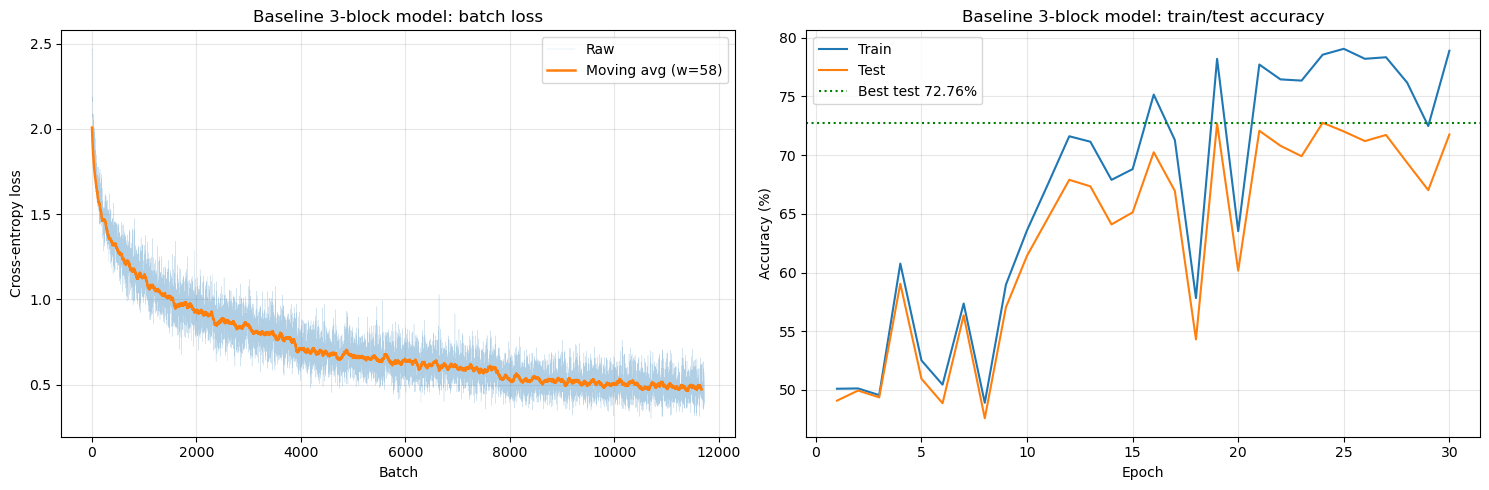

In [8]:
RUN_BASELINE = True

if RUN_BASELINE:
    set_seed(123)
    baseline_model = CIFAR10Net(baseline_configs, pool_after={0, 1}).to(device)
    baseline_model.apply(init_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        baseline_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    baseline_result = train_model(
        baseline_model,
        train_loader,
        train_eval_loader,
        test_loader,
        optimizer,
        scheduler,
        criterion,
        num_epochs=30,
        name="baseline_3block",
        print_every=5,
    )
    plot_training_trace(baseline_result, "Baseline 3-block model")


## 5. Screening Experiments

Eperiments related to increasing the model's parameter capacity are screened first (width, depth, kernel branches) and optimisation/regularisation second (augmentation, optimiser, schedule, momentum, weight decay, label smoothing). All runs use a fixed 50-epoch budget for direct comparability.

In [9]:
RUN_SCREENING = True
SCREENING_EPOCHS = 50
screening_results = []


def run_screening_experiment(name, configs, pool_after, augmentation, lr=0.1,
                             momentum=0.9, weight_decay=1e-4,
                             optimizer_name="sgd", scheduler_name="cosine",
                             label_smoothing=0.0):
    tr, tr_eval, te = get_loaders(batch_size=128, augmentation=augmentation)
    set_seed(123)
    model = CIFAR10Net(configs, pool_after=pool_after).to(device)
    model.apply(init_weights)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    if optimizer_name == "sgd":
        optimizer = optim.SGD(
            model.parameters(), lr=lr, momentum=momentum,
            weight_decay=weight_decay, nesterov=True
        )
    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    if scheduler_name == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SCREENING_EPOCHS)
        scheduler_per_batch = False
    elif scheduler_name == "step":
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
        scheduler_per_batch = False
    elif scheduler_name == "one_cycle":
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, steps_per_epoch=len(tr), epochs=SCREENING_EPOCHS
        )
        scheduler_per_batch = True
    elif scheduler_name == "warm_restarts":
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=1)
        scheduler_per_batch = False
    else:
        raise ValueError(scheduler_name)

    result = train_model(
        model, tr, tr_eval, te, optimizer, scheduler, criterion,
        num_epochs=SCREENING_EPOCHS, name=name,
        scheduler_per_batch=scheduler_per_batch, print_every=15
    )
    result["augmentation"] = augmentation
    result["optimizer_name"] = optimizer_name
    result["scheduler_name"] = scheduler_name
    result["lr"] = lr
    result["momentum"] = momentum
    result["weight_decay"] = weight_decay
    result["label_smoothing"] = label_smoothing
    return result


### 5.1 Capacity

In [10]:
if RUN_SCREENING:
    for width in ["narrow", "medium", "wide"]:
        screening_results.append(run_screening_experiment(
            name=f"E1_width_{width}",
            configs=make_3block(width=width),
            pool_after={0, 1},
            augmentation="basic",
        ))

    for name, cfgs, pools in [
        ("E2_depth_3block", make_3block(width="medium"), {0, 1}),
        ("E2_depth_5block", make_5block((3, 3, 3)), {1, 3}),
        ("E2_depth_7block", make_7block((3, 3, 3)), {1, 3, 5}),
    ]:
        screening_results.append(run_screening_experiment(
            name=name,
            configs=cfgs,
            pool_after=pools,
            augmentation="basic",
        ))

    for kernels in [(3, 3, 3), (1, 3, 5), (3, 5, 7)]:
        screening_results.append(run_screening_experiment(
            name=f"E3_kernels_{kernels}",
            configs=make_5block(kernels),
            pool_after={1, 3},
            augmentation="basic",
        ))


[E1_width_narrow] epoch   1/50 loss 1.4509 train 44.70% test 44.20% best 44.20% lr 0.09990 time 0.1m
[E1_width_narrow] epoch  15/50 loss 0.5808 train 75.59% test 73.79% best 74.68% lr 0.07939 time 1.7m
[E1_width_narrow] epoch  30/50 loss 0.4346 train 82.73% test 78.86% best 80.26% lr 0.03455 time 3.5m
[E1_width_narrow] epoch  45/50 loss 0.3200 train 90.10% test 84.91% best 84.91% lr 0.00245 time 5.2m
[E1_width_narrow] epoch  50/50 loss 0.3108 train 90.38% test 84.97% best 85.03% lr 0.00000 time 5.8m

[E1_width_medium] epoch   1/50 loss 1.4202 train 45.33% test 45.20% best 45.20% lr 0.09990 time 0.2m
[E1_width_medium] epoch  15/50 loss 0.4920 train 74.64% test 71.76% best 72.81% lr 0.07939 time 2.1m
[E1_width_medium] epoch  30/50 loss 0.3108 train 85.25% test 80.23% best 82.79% lr 0.03455 time 4.1m
[E1_width_medium] epoch  45/50 loss 0.1850 train 95.01% test 86.87% best 86.87% lr 0.00245 time 6.2m
[E1_width_medium] epoch  50/50 loss 0.1724 train 95.31% test 87.15% best 87.15% lr 0.00000

### 5.2 Optimisation and Regularisation

In [11]:
if RUN_SCREENING:
    for aug in ["none", "basic", "moderate"]:
        screening_results.append(run_screening_experiment(
            name=f"E4_aug_{aug}",
            configs=make_3block(width="medium"),
            pool_after={0, 1},
            augmentation=aug,
        ))

    optimizer_experiments = [
        ("E5_sgd_lr0.01", "sgd", 0.01, 1e-4),
        ("E5_sgd_lr0.05", "sgd", 0.05, 1e-4),
        ("E5_sgd_lr0.1", "sgd", 0.1, 1e-4),
        ("E5_adam_lr1e-3", "adam", 1e-3, 1e-4),
        ("E5_adamw_lr1e-3", "adamw", 1e-3, 1e-2),
    ]
    for name, opt_name, lr, wd in optimizer_experiments:
        screening_results.append(run_screening_experiment(
            name=name,
            configs=make_5block((1, 3, 5)),
            pool_after={1, 3},
            augmentation="basic",
            optimizer_name=opt_name,
            lr=lr,
            weight_decay=wd,
        ))

    for name, schedule_name in [
        ("E6_schedule_step", "step"),
        ("E6_schedule_cosine", "cosine"),
        ("E6_schedule_one_cycle", "one_cycle"),
        ("E6_schedule_warm_restarts", "warm_restarts"),
    ]:
        screening_results.append(run_screening_experiment(
            name=name,
            configs=make_5block((1, 3, 5)),
            pool_after={1, 3},
            augmentation="basic",
            scheduler_name=schedule_name,
        ))

    for momentum in [0.7, 0.8, 0.9, 0.95]:
        screening_results.append(run_screening_experiment(
            name=f"E7_momentum_{momentum}",
            configs=make_5block((1, 3, 5)),
            pool_after={1, 3},
            augmentation="basic",
            momentum=momentum,
        ))

    for wd in [0.0, 1e-4, 5e-4, 1e-3]:
        screening_results.append(run_screening_experiment(
            name=f"E8_weight_decay_{wd:g}",
            configs=make_5block((1, 3, 5)),
            pool_after={1, 3},
            augmentation="basic",
            momentum=0.95,
            weight_decay=wd,
        ))

    for smoothing in [0.0, 0.05, 0.1]:
        screening_results.append(run_screening_experiment(
            name=f"E9_label_smoothing_{smoothing:g}",
            configs=make_5block((1, 3, 5)),
            pool_after={1, 3},
            augmentation="basic",
            momentum=0.95,
            weight_decay=5e-4,
            label_smoothing=smoothing,
        ))


[E4_aug_none] epoch   1/50 loss 1.3278 train 38.83% test 38.68% best 38.68% lr 0.09990 time 0.1m
[E4_aug_none] epoch  15/50 loss 0.2780 train 69.50% test 63.10% best 75.36% lr 0.07939 time 1.8m
[E4_aug_none] epoch  30/50 loss 0.0291 train 97.69% test 80.38% best 80.38% lr 0.03455 time 3.5m
[E4_aug_none] epoch  45/50 loss 0.0104 train 100.00% test 84.41% best 84.41% lr 0.00245 time 5.2m
[E4_aug_none] epoch  50/50 loss 0.0098 train 100.00% test 84.51% best 84.58% lr 0.00000 time 5.8m

[E4_aug_basic] epoch   1/50 loss 1.4202 train 45.33% test 45.20% best 45.20% lr 0.09990 time 0.1m
[E4_aug_basic] epoch  15/50 loss 0.4920 train 74.64% test 71.76% best 72.81% lr 0.07939 time 1.7m
[E4_aug_basic] epoch  30/50 loss 0.3108 train 85.25% test 80.23% best 82.79% lr 0.03455 time 3.5m
[E4_aug_basic] epoch  45/50 loss 0.1850 train 95.01% test 86.87% best 86.87% lr 0.00245 time 5.2m
[E4_aug_basic] epoch  50/50 loss 0.1724 train 95.31% test 87.15% best 87.15% lr 0.00000 time 5.8m

[E4_aug_moderate] epo

### 5.3 Summary

In [12]:
if screening_results:
    screening_df = pd.DataFrame([{
        "experiment": r["name"],
        "best_test": round(r["best_test_acc"], 2),
        "best_epoch": r["best_epoch"],
        "params": r["num_params"],
        "time_min": round(r["total_time"] / 60, 1),
        "augmentation": r["augmentation"],
        "optimizer": r["optimizer_name"],
        "scheduler": r["scheduler_name"],
        "lr": r["lr"],
        "momentum": r["momentum"],
        "weight_decay": r["weight_decay"],
    } for r in screening_results]).sort_values("best_test", ascending=False)

    def experiment_group(name):
        if name.startswith("E1_"): return "width"
        if name.startswith("E2_"): return "depth"
        if name.startswith("E3_"): return "kernels"
        if name.startswith("E4_"): return "augmentation"
        if name.startswith("E5_"): return "optimiser/LR"
        if name.startswith("E6_"): return "scheduler"
        if name.startswith("E7_"): return "momentum"
        if name.startswith("E8_"): return "weight decay"
        if name.startswith("E9_"): return "label smoothing"
        return "other"

    screening_df["group"] = screening_df["experiment"].map(experiment_group)
    best_by_group = screening_df.loc[screening_df.groupby("group")["best_test"].idxmax()]
else:
    raise RuntimeError("No screening results found. Set RUN_SCREENING = True and run the screening cells.")

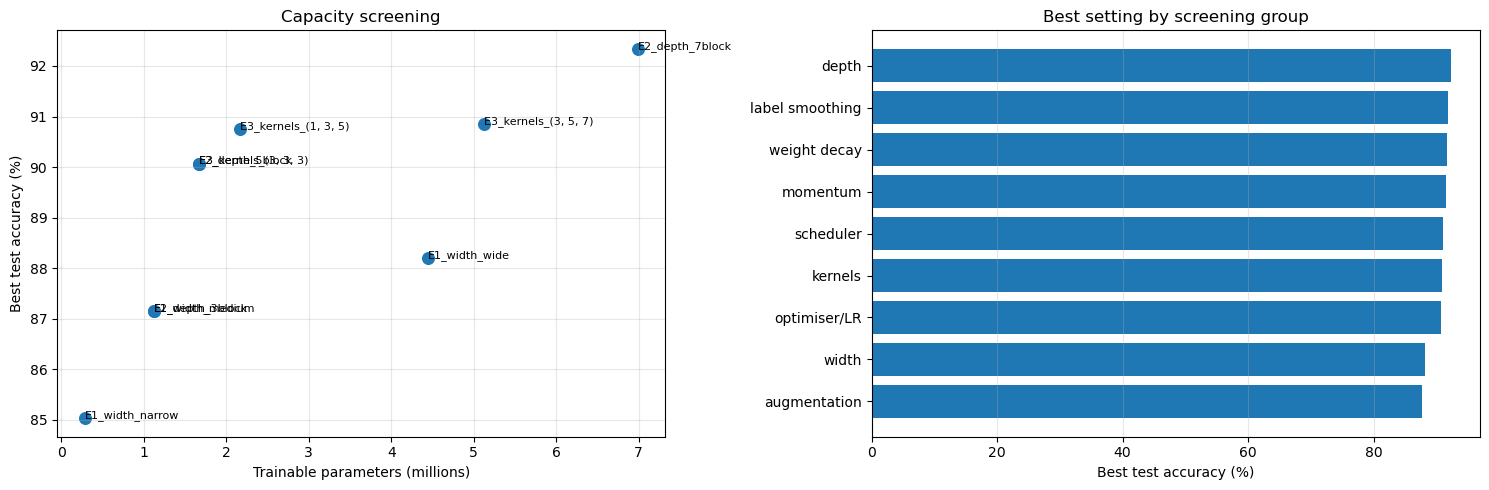

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

capacity_df = screening_df[screening_df["group"].isin(["width", "depth", "kernels"])]
axes[0].scatter(capacity_df["params"] / 1e6, capacity_df["best_test"], s=70)
for _, row in capacity_df.iterrows():
    axes[0].annotate(row["experiment"], (row["params"] / 1e6, row["best_test"]), fontsize=8)
axes[0].set_xlabel("Trainable parameters (millions)")
axes[0].set_ylabel("Best test accuracy (%)")
axes[0].set_title("Capacity screening")
axes[0].grid(True, alpha=0.3)

best_plot = best_by_group.sort_values("best_test")
axes[1].barh(best_plot["group"], best_plot["best_test"])
axes[1].set_xlabel("Best test accuracy (%)")
axes[1].set_title("Best setting by screening group")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

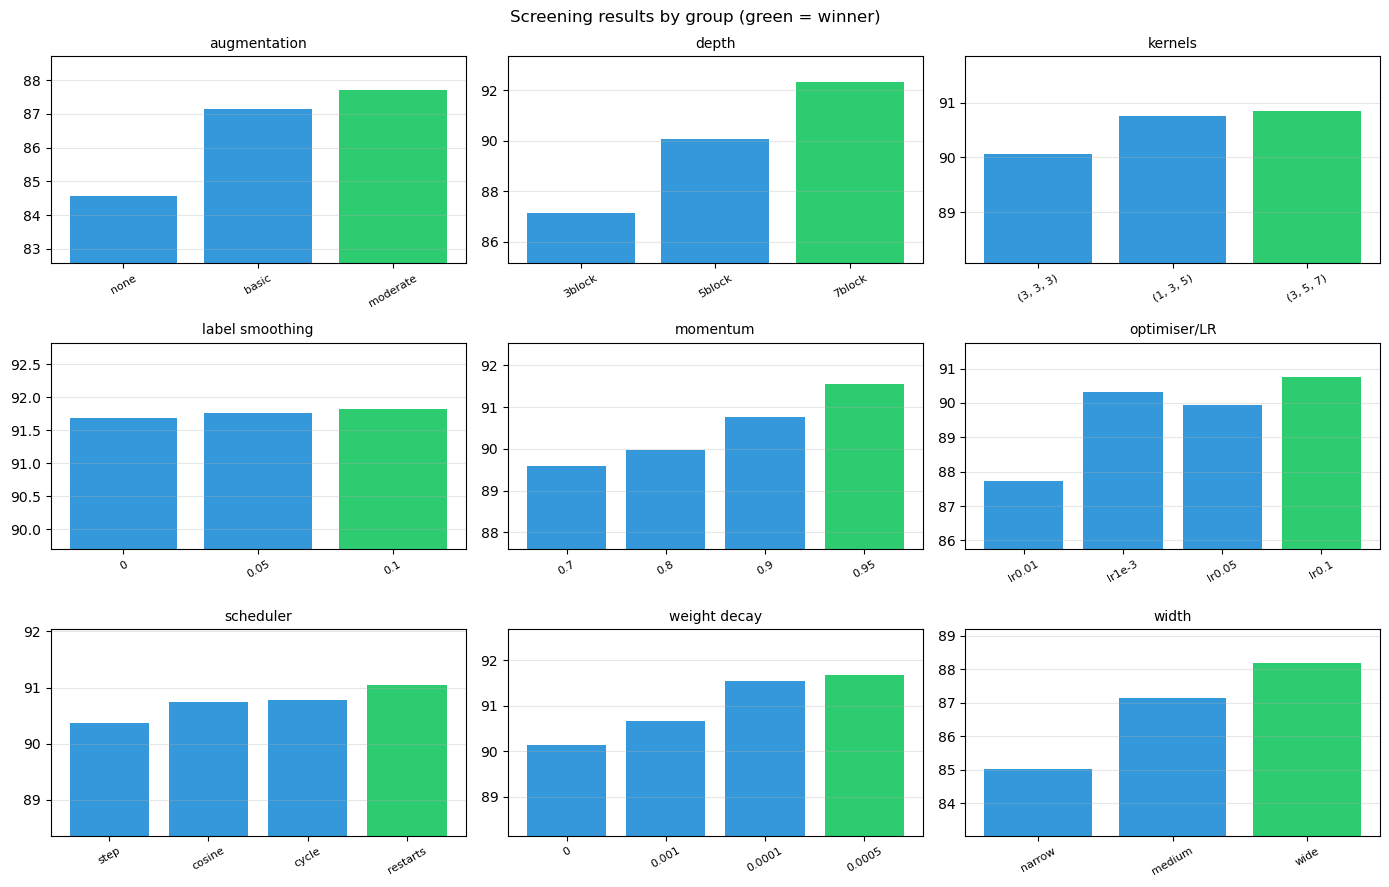

In [14]:
groups_list = sorted(screening_df["group"].unique())
ncols = 3
nrows = -(-len(groups_list) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for ax_i, group in enumerate(groups_list):
    group_df = screening_df[screening_df["group"] == group].sort_values("best_test")
    labels = group_df["experiment"].str.split("_").str[-1]
    vals = group_df["best_test"].values
    colours = ["#2ecc71" if v == vals.max() else "#3498db" for v in vals]
    axes[ax_i].bar(labels, vals, color=colours)
    axes[ax_i].set_title(group, fontsize=10)
    axes[ax_i].set_ylim(vals.min() - 2, vals.max() + 1)
    axes[ax_i].tick_params(axis="x", rotation=30, labelsize=8)
    axes[ax_i].grid(axis="y", alpha=0.3)

for ax_i in range(len(groups_list), len(axes)):
    axes[ax_i].set_visible(False)

plt.suptitle("Screening results by group (green = winner)", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Final Model Comparison

The final comparison uses one training recipe for two capacities:

- medium model: 5 intermediate blocks with [3,5,7] branches;
- large model: 7 intermediate blocks with [3,5,7] branches and 20M+ parameters.

This makes the accuracy/compute trade-off explicit. The large model is expected to score
higher, but the medium model provides a useful comparison point for parameter efficiency.


Preliminary 100-epoch warm-restart runs showed the best test accuracy was always reached just before the learning rate reset at epoch 50, with the second cycle consistently failing to surpass it. The final comparison therefore uses a 50-epoch single cosine decay to avoid this.



In [15]:
FINAL_KERNELS = (3, 5, 7)
FINAL_EPOCHS = 50
FINAL_LR = 0.1
FINAL_MOMENTUM = 0.95
FINAL_WEIGHT_DECAY = 5e-4
FINAL_LABEL_SMOOTHING = 0.1

FINAL_SPECS = [
    {
        "name": "medium_5block_357",
        "configs": make_5block(FINAL_KERNELS),
        "pool_after": {1, 3},
        "checkpoint": "medium_5block_357.pt",
    },
    {
        "name": "large_7block_357",
        "configs": make_7block(FINAL_KERNELS),
        "pool_after": {1, 3, 5},
        "checkpoint": "large_7block_357.pt",
    },
]

for spec in FINAL_SPECS:
    tmp_model = CIFAR10Net(spec["configs"], pool_after=spec["pool_after"]).to(device)
    print(f"{spec['name']}: {count_params(tmp_model):,} trainable parameters")
    del tmp_model
    if USE_CUDA:
        torch.cuda.empty_cache()


medium_5block_357: 5,123,042 trainable parameters
large_7block_357: 21,450,216 trainable parameters


In [16]:
RUN_FINAL_COMPARISON = True

final_results = []
if RUN_FINAL_COMPARISON:
    final_train_loader, final_train_eval_loader, final_test_loader = get_loaders(
        batch_size=128, augmentation="moderate"
    )

    for spec in FINAL_SPECS:
        set_seed(123)
        model = CIFAR10Net(spec["configs"], pool_after=spec["pool_after"]).to(device)
        model.apply(init_weights)

        criterion = nn.CrossEntropyLoss(label_smoothing=FINAL_LABEL_SMOOTHING)
        optimizer = optim.SGD(
            model.parameters(),
            lr=FINAL_LR,
            momentum=FINAL_MOMENTUM,
            weight_decay=FINAL_WEIGHT_DECAY,
            nesterov=True,
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FINAL_EPOCHS
        )

        result = train_model(
            model,
            final_train_loader,
            final_train_eval_loader,
            final_test_loader,
            optimizer,
            scheduler,
            criterion,
            num_epochs=FINAL_EPOCHS,
            name=spec["name"],
            print_every=5,
        )
        result["checkpoint"] = spec["checkpoint"]
        result["configs"] = spec["configs"]
        result["pool_after"] = spec["pool_after"]
        final_results.append(result)

        torch.save({
            "state_dict": result["best_state"],
            "best_test_acc": result["best_test_acc"],
            "best_epoch": result["best_epoch"],
            "block_configs": spec["configs"],
            "pool_after": sorted(spec["pool_after"]),
            "num_epochs": FINAL_EPOCHS,
            "label_smoothing": FINAL_LABEL_SMOOTHING,
            "momentum": FINAL_MOMENTUM,
            "weight_decay": FINAL_WEIGHT_DECAY,
        }, spec["checkpoint"])
        print(f"Saved {spec['checkpoint']}")

        if USE_CUDA:
            torch.cuda.empty_cache()


[medium_5block_357] epoch   1/50 loss 1.7351 train 50.01% test 49.51% best 49.51% lr 0.09990 time 0.2m
[medium_5block_357] epoch   5/50 loss 1.0148 train 78.02% test 75.93% best 75.93% lr 0.09755 time 1.0m
[medium_5block_357] epoch  10/50 loss 0.9263 train 77.04% test 74.69% best 75.93% lr 0.09045 time 2.0m
[medium_5block_357] epoch  15/50 loss 0.8843 train 83.81% test 80.51% best 80.51% lr 0.07939 time 3.0m
[medium_5block_357] epoch  20/50 loss 0.8452 train 83.10% test 79.74% best 83.14% lr 0.06545 time 4.0m
[medium_5block_357] epoch  25/50 loss 0.8027 train 87.84% test 84.27% best 84.27% lr 0.05000 time 5.0m
[medium_5block_357] epoch  30/50 loss 0.7516 train 87.41% test 82.12% best 84.27% lr 0.03455 time 6.0m
[medium_5block_357] epoch  35/50 loss 0.6878 train 95.24% test 88.01% best 88.01% lr 0.02061 time 7.0m
[medium_5block_357] epoch  40/50 loss 0.6146 train 98.26% test 90.38% best 90.38% lr 0.00955 time 8.0m
[medium_5block_357] epoch  45/50 loss 0.5631 train 99.82% test 91.91% bes

,model,params,best_test,best_epoch,final_train,final_test,time_min,checkpoint
1,large_7block_357,21450216,93.74,50,99.99,93.74,12.8,large_7block_357.pt
0,medium_5block_357,5123042,92.47,49,99.94,92.45,10.0,medium_5block_357.pt


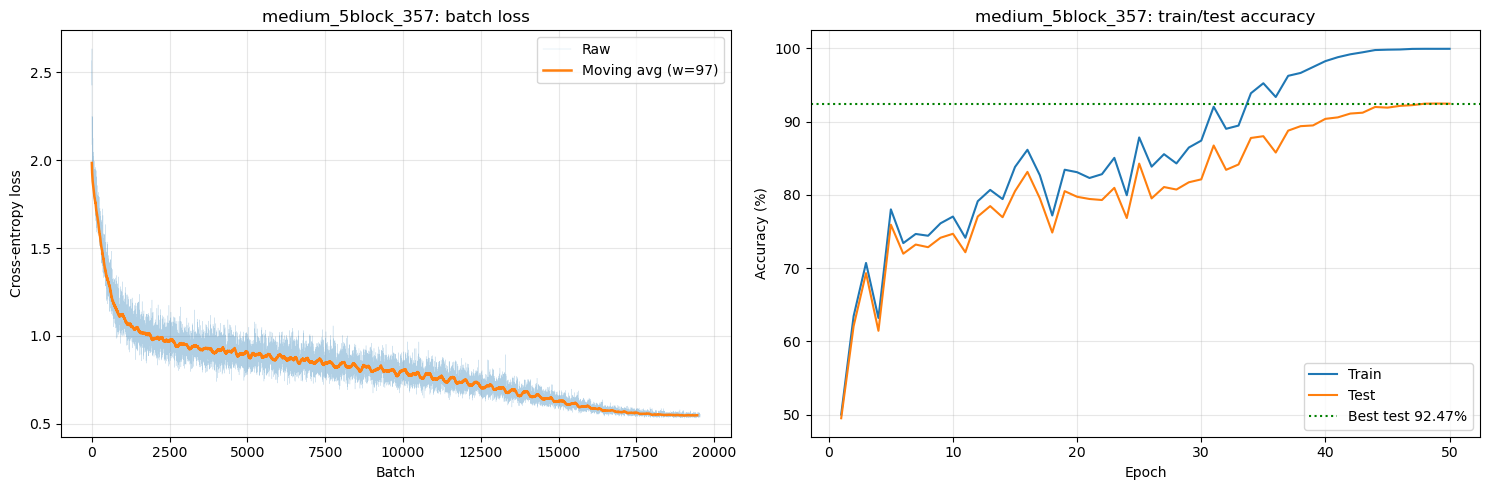

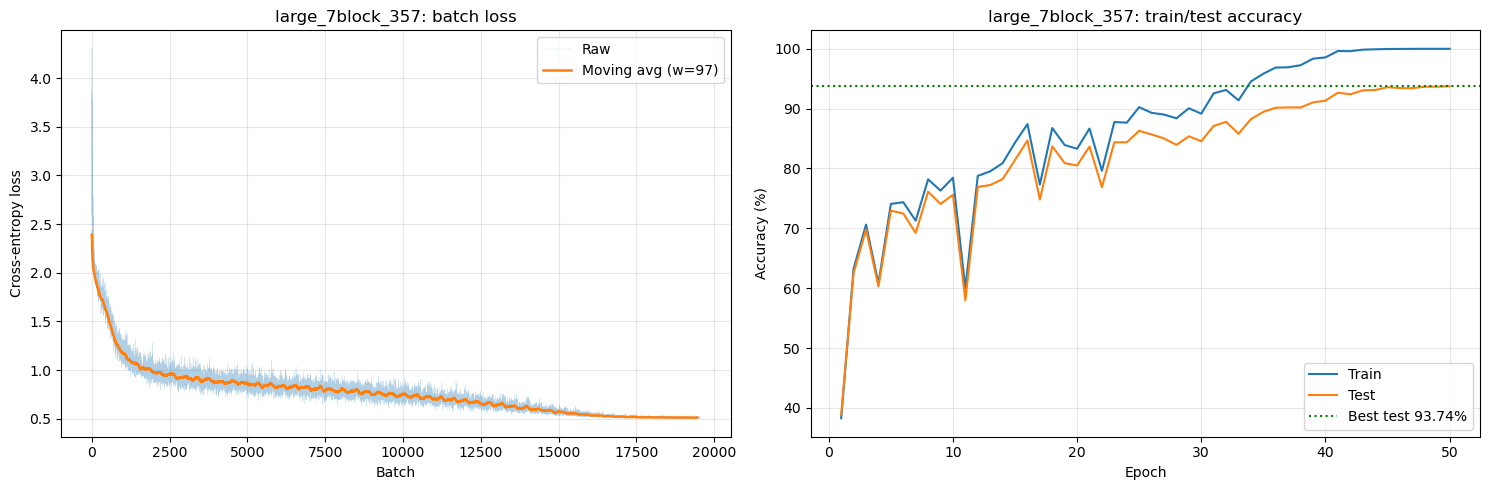

In [17]:
if final_results:
    final_summary = pd.DataFrame([{
        "model": r["name"],
        "params": r["num_params"],
        "best_test": round(r["best_test_acc"], 2),
        "best_epoch": r["best_epoch"],
        "final_train": round(r["train_accs"][-1], 2),
        "final_test": round(r["test_accs"][-1], 2),
        "time_min": round(r["total_time"] / 60, 1),
        "checkpoint": r["checkpoint"],
    } for r in final_results]).sort_values("best_test", ascending=False)
    display(final_summary)

    for result in final_results:
        plot_training_trace(result, result["name"])
else:
    print("No final results yet. Set RUN_FINAL_COMPARISON = True and run the final training cell.")


## 7. Results Analysis

### 7.1 Baseline

The 3-block baseline (3 → 32 → 64 → 128, SGD lr=0.01, StepLR, 30 epochs, no augmentation) reached **72.8% test accuracy**. This confirms the architecture is correctly implemented and provides the reference point for the screening experiments.

### 7.2 Capacity screening (E1–E3)

| Experiment | Best test | Params |
|---|---|---|
| E1 narrow (32→64→128) | 85.0% | ~282K |
| E1 medium (64→128→256) | 87.2% | ~1.1M |
| E1 wide (128→256→512) | 88.2% | ~4.4M |
| E2 3-block | 87.2% | ~1.1M |
| E2 5-block | 90.1% | ~1.7M |
| E2 7-block | 92.3% | ~7.0M |

Depth was the single strongest capacity lever, the 7-block model (92.3%) outperformed the wide 3-block model (88.2%) without any augmentation. Width increases accuracy consistently, but with greater diminishing returns compared to depth increases. The 5-block → 7-block step gave +2.2% for a 4× parameter increase, already achieving the 92% target mentioned in the assignment brief, confirming depth should be prioritised in the final model.

### 7.3 Optimisation and regularisation screening (E4–E9)

Key findings:

- **Augmentation (E4):** `moderate` (flip + crop + ColorJitter) reached 87.7%, ahead of `basic` (87.2%) and well ahead of none (84.6%). Augmentation provides a consistent +2–3% by regularising models that otherwise reach 100% training accuracy.
- **Optimiser/LR (E5):** SGD lr=0.1 reached 90.8%, clearly the best. Lower learning rates converged more slowly and to a lower peak. Adam-based optimisers underperformed SGD consistently in this architecture.
- **Other settings** (momentum=0.95, wd=5e-4, label smoothing=0.1, CosineAnnealingLR) each contributed smaller individual gains and were combined for the final model.

### 7.4 Final model

| Model | Params | Best test | Training time |
|---|---|---|---|
| medium\_5block\_357 | 5.1M | 92.5% | 10.0 min |
| large\_7block\_357 | 21.5M | **93.7%** | 12.8 min |

Both models used [3,5,7] multi-scale kernels, moderate augmentation, SGD lr=0.1 momentum=0.95, weight\_decay=5e-4, label\_smoothing=0.1, and CosineAnnealingLR over 50 epochs.

The large model (93.7%) exceeds the 92% threshold for maximum marks. The medium model (92.5%) also clears that threshold at roughly one quarter of the parameter count and 78% of the training time. The [3,5,7] multi-scale branches appear especially beneficial at greater depth for two reasons. Firstly, by the later blocks spatial resolution has been halved multiple times, so a 7×7 kernel covers a proportionally large region of the remaining feature map, capturing context that a 3×3 kernel would miss entirely. Secondly, as the network deepens, feature maps become more semantically rich, giving the attention mechanism a stronger signal to decide which receptive field size is most relevant for each image. At shallow depth both effects are weaker, spatial dimensions are still large so kernel size matters less, and low-level features carry little discriminative signal for the attention weights.